# Exploratory Data Analysis: Financial Inclusion Dataset
## Understanding Bank Account Ownership Across Demographics

### 1. Setup & Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [5]:
train = pd.read_csv('data/Train.csv')
test = pd.read_csv('data/Test.csv')
sample_submission = pd.read_csv('data/SampleSubmission.csv')
var_def = pd.read_csv('data/VariableDefinitions.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

Train shape: (23524, 13)
Test shape: (10086, 12)
Sample submission shape: (33610, 2)


### 2. Dataset Overview

In [6]:
# First look at the data
print("First 5 rows:")
print(train.head())
print("\nData types:")
print(train.dtypes)
print("\nBasic info:")
train.info()

First 5 rows:
  country  year    uniqueid bank_account location_type cellphone_access   
0   Kenya  2018  uniqueid_1          Yes         Rural              Yes  \
1   Kenya  2018  uniqueid_2           No         Rural               No   
2   Kenya  2018  uniqueid_3          Yes         Urban              Yes   
3   Kenya  2018  uniqueid_4           No         Rural              Yes   
4   Kenya  2018  uniqueid_5           No         Urban               No   

   household_size  age_of_respondent gender_of_respondent   
0               3                 24               Female  \
1               5                 70               Female   
2               5                 26                 Male   
3               5                 34               Female   
4               8                 26                 Male   

  relationship_with_head           marital_status   
0                 Spouse  Married/Living together  \
1      Head of Household                  Widowed   
2        

In [7]:
# Separate numeric and categorical columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

Numeric columns: ['year', 'household_size', 'age_of_respondent']
Categorical columns: ['country', 'uniqueid', 'bank_account', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


### 3. Missing Values Analysis

In [8]:
# Check missing values
missing_data = pd.DataFrame({
    'Column': train.columns,
    'Missing_Count': train.isnull().sum(),
    'Missing_Percentage': (train.isnull().sum() / len(train)) * 100
}).sort_values('Missing_Percentage', ascending=False)

print(missing_data[missing_data['Missing_Count'] > 0])
if missing_data['Missing_Count'].sum() == 0:
    print("No missing values in the dataset!")

Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []
No missing values in the dataset!


In [9]:
# Visualize missing values
plt.figure(figsize=(10, 4))
missing_pct = (train.isnull().sum() / len(train)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
if len(missing_pct) > 0:
    missing_pct.plot(kind='barh', color='coral')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to visualize")

No missing values to visualize


<Figure size 1000x400 with 0 Axes>

### 4. Target Variable Analysis

In [10]:
# Target variable distribution
print("Bank Account Distribution:")
print(train['bank_account'].value_counts())
print(f"\nPercentage:")
print(train['bank_account'].value_counts(normalize=True) * 100)

Bank Account Distribution:
bank_account
No     20212
Yes     3312
Name: count, dtype: int64

Percentage:
bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64


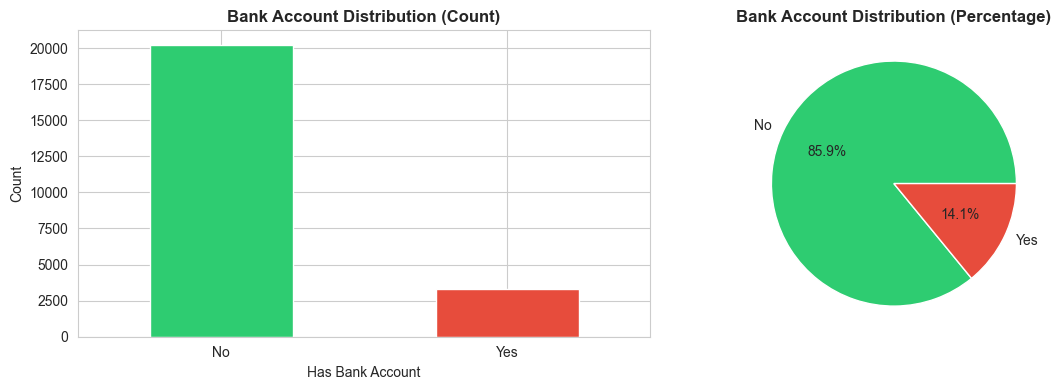

In [11]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
train['bank_account'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Bank Account Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Has Bank Account')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
train['bank_account'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                            colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Bank Account Distribution (Percentage)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [12]:
# Class imbalance ratio
class_counts = train['bank_account'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f}:1")

Class Imbalance Ratio: 6.10:1


### 5. Numerical Columns Analysis

In [13]:
# Descriptive statistics for numeric columns
print("Descriptive Statistics for Numeric Columns:")
train[numeric_cols].describe().T

Descriptive Statistics for Numeric Columns:


,count,mean,std,min,25%,50%,75%,max
year,23524.0,2016.975939,0.847371,2016.0,2016.0,2017.0,2018.0,2018.0
household_size,23524.0,3.797483,2.227613,1.0,2.0,3.0,5.0,21.0
age_of_respondent,23524.0,38.805220,16.520569,16.0,26.0,35.0,49.0,100.0


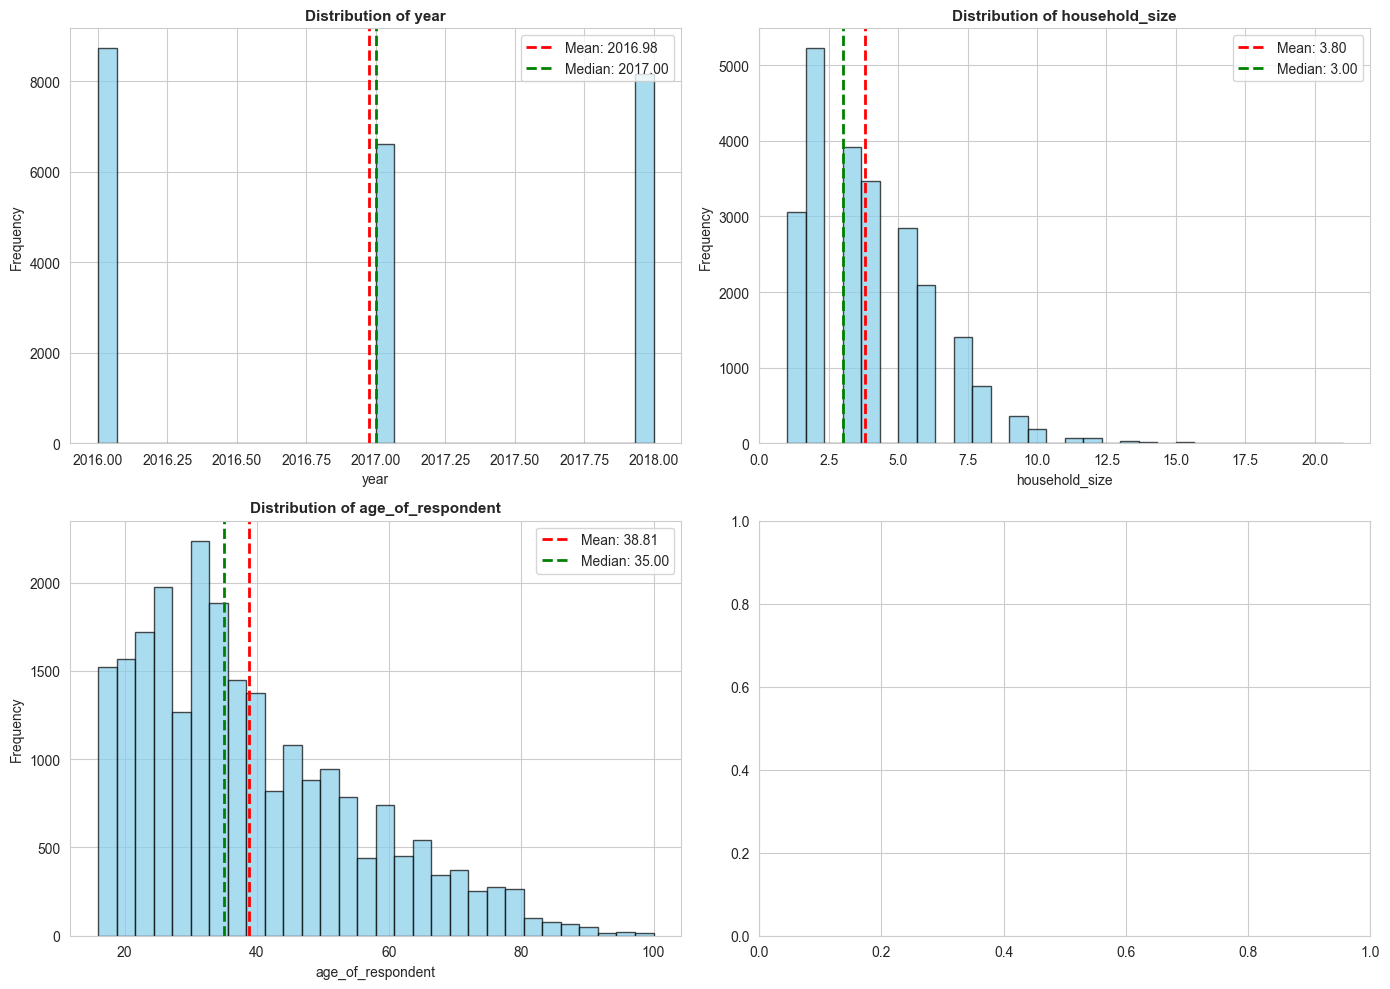

In [14]:
# Distribution of numeric columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(train[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(train[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train[col].mean():.2f}')
    axes[idx].axvline(train[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {train[col].median():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [15]:
# Check for outliers using IQR method
print("Outlier Analysis (IQR Method):")
for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(train)*100:.2f}%)")

Outlier Analysis (IQR Method):
year: 0 outliers (0.00%)
household_size: 381 outliers (1.62%)
age_of_respondent: 241 outliers (1.02%)


### 6. Categorical Columns Analysis

In [16]:
# Value counts for categorical columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(train[col].value_counts())
    print(f"Unique values: {train[col].nunique()}")


country:
country
Rwanda      8735
Tanzania    6620
Kenya       6068
Uganda      2101
Name: count, dtype: int64
Unique values: 4

uniqueid:
uniqueid
uniqueid_1       4
uniqueid_1413    4
uniqueid_1411    4
uniqueid_1410    4
uniqueid_1409    4
                ..
uniqueid_7318    1
uniqueid_7317    1
uniqueid_7316    1
uniqueid_7315    1
uniqueid_8759    1
Name: count, Length: 8735, dtype: int64
Unique values: 8735

bank_account:
bank_account
No     20212
Yes     3312
Name: count, dtype: int64
Unique values: 2

location_type:
location_type
Rural    14343
Urban     9181
Name: count, dtype: int64
Unique values: 2

cellphone_access:
cellphone_access
Yes    17454
No      6070
Name: count, dtype: int64
Unique values: 2

gender_of_respondent:
gender_of_respondent
Female    13877
Male       9647
Name: count, dtype: int64
Unique values: 2

relationship_with_head:
relationship_with_head
Head of Household      12831
Spouse                  6520
Child                   2229
Parent                 

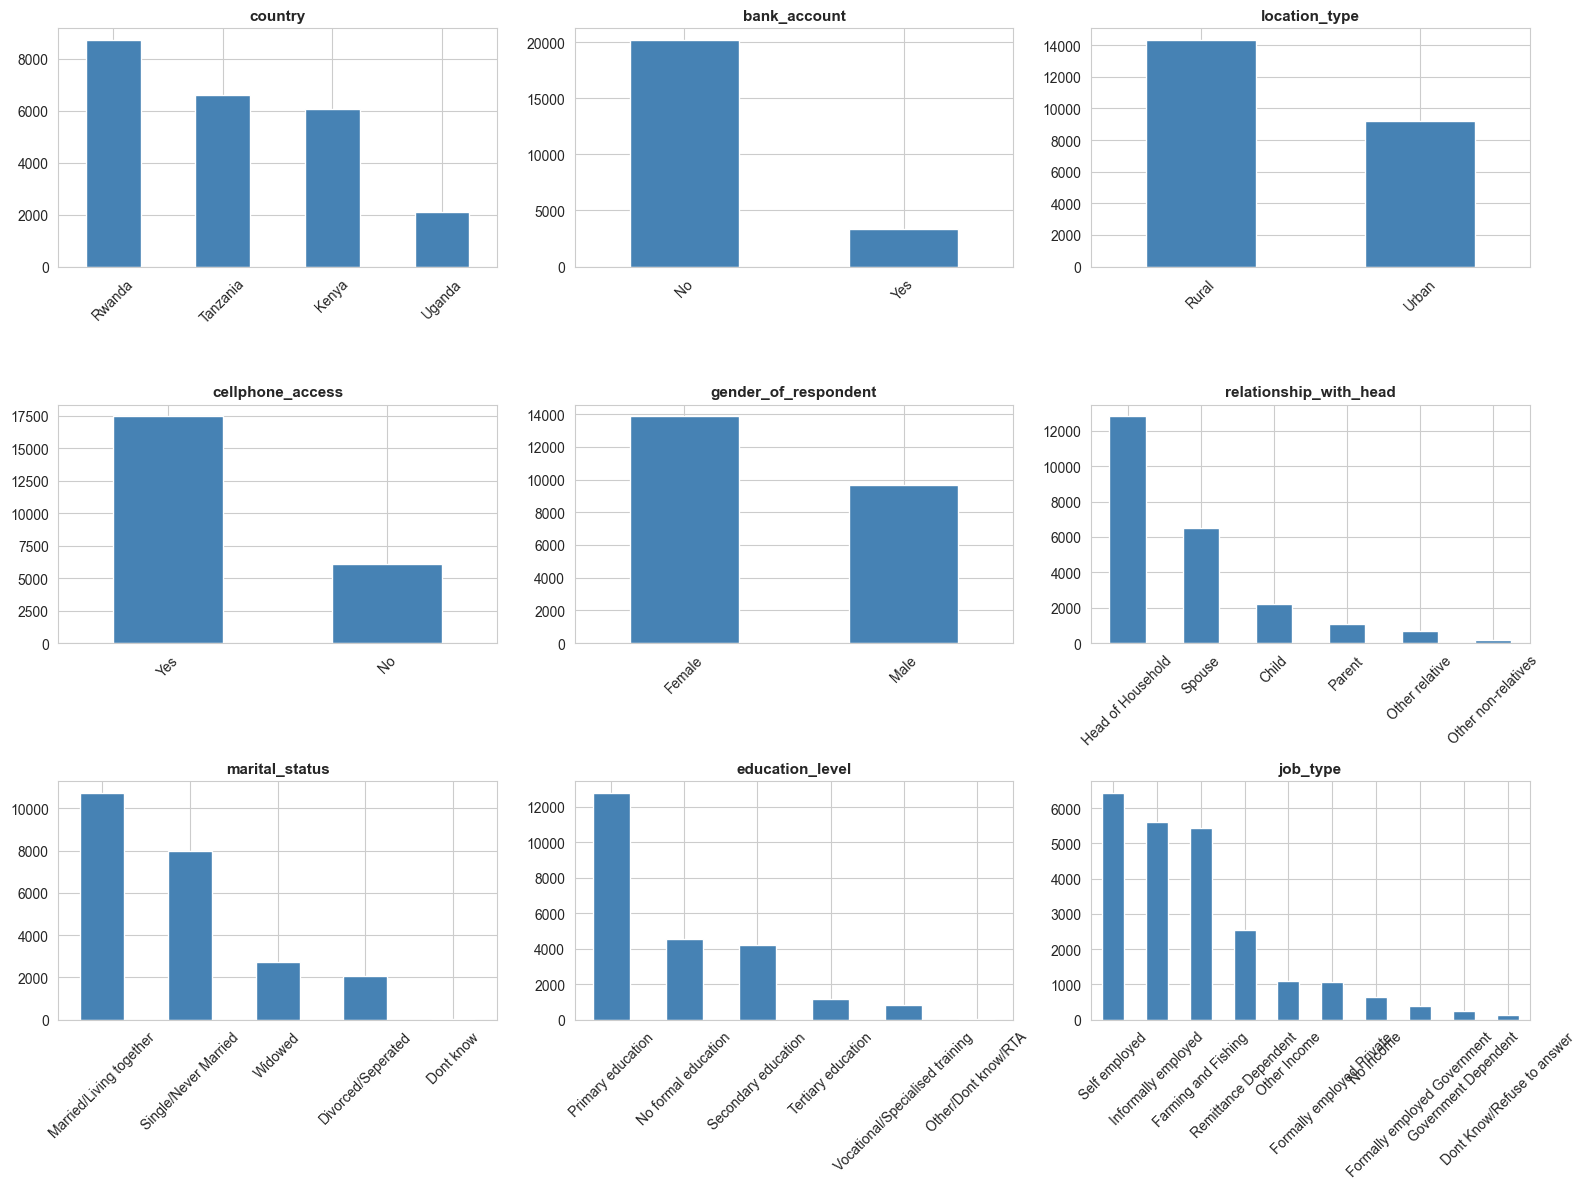

In [17]:
# Visualize categorical distributions (excluding uniqueid)
categorical_cols_to_plot = [col for col in categorical_cols if col != 'uniqueid']
num_cols = len(categorical_cols_to_plot)
ncols = 3
nrows = (num_cols + ncols - 1) // ncols  # Calculate rows dynamically

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols_to_plot):
    train[col].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(categorical_cols_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### 7. Bivariate Analysis: Features vs Target

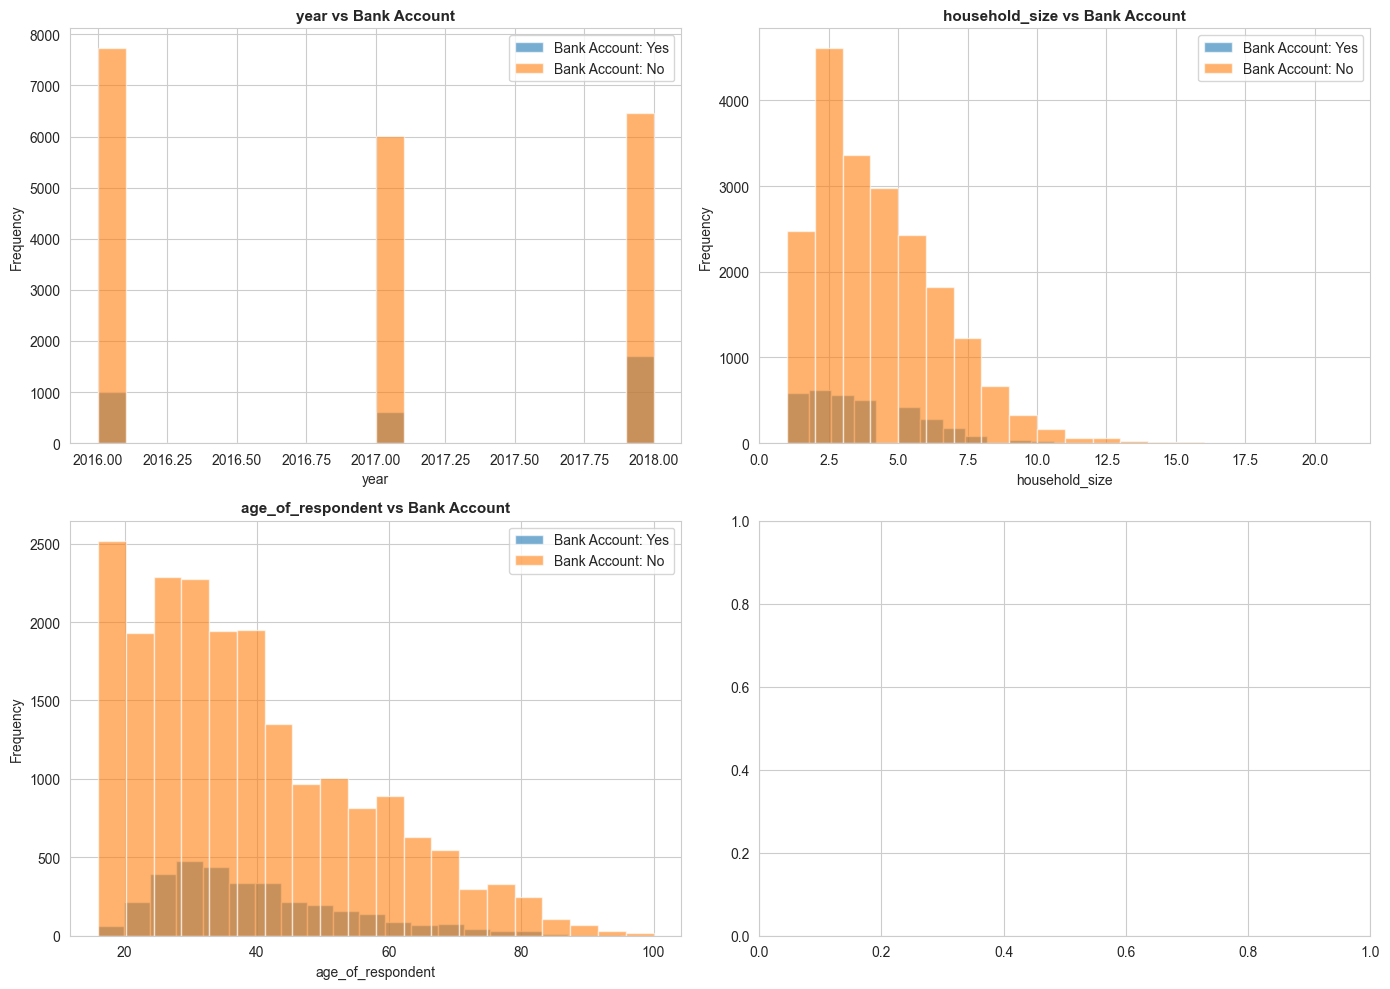

In [27]:
# Numeric features vs target - Distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    for bank_val in train['bank_account'].unique():
        axes[idx].hist(train[train['bank_account'] == bank_val][col], bins=20, 
                      alpha=0.6, label=f'Bank Account: {bank_val}')
    axes[idx].set_title(f'{col} vs Bank Account', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [19]:
# Statistical significance for numeric features
print("Statistical Test Results (Independent t-test):")
print("H0: There is no difference in mean between Yes and No groups\n")

for col in numeric_cols:
    yes_group = train[train['bank_account'] == 'Yes'][col]
    no_group = train[train['bank_account'] == 'No'][col]
    t_stat, p_value = stats.ttest_ind(yes_group, no_group)
    significant = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{col}: p-value = {p_value:.2e} {significant}")

Statistical Test Results (Independent t-test):
H0: There is no difference in mean between Yes and No groups

year: p-value = 6.58e-67 ***
household_size: p-value = 1.39e-05 ***
age_of_respondent: p-value = 2.88e-03 **


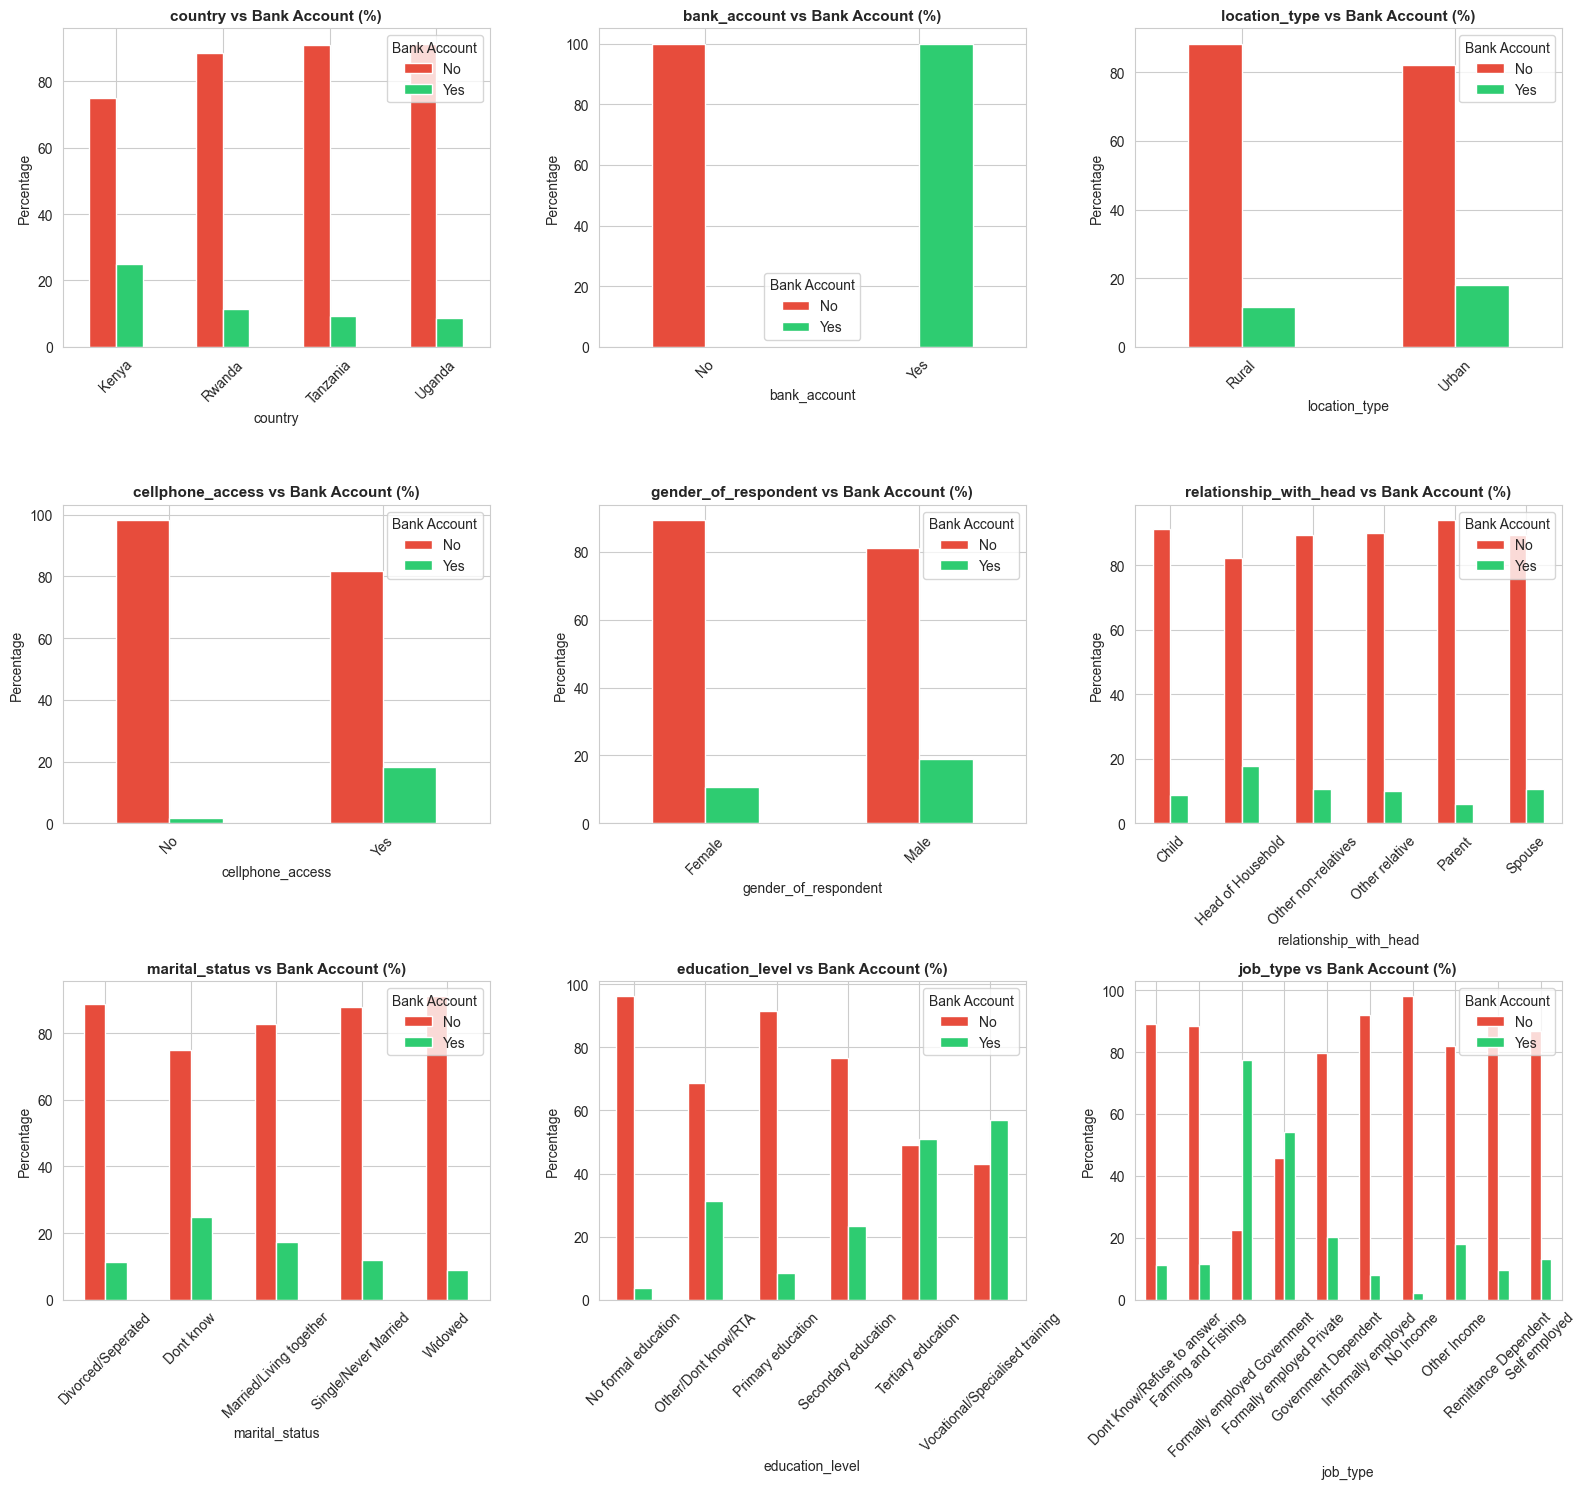

In [20]:
# Categorical features vs target
categorical_cols_list = [col for col in categorical_cols if col != 'uniqueid']
num_cols_to_plot = len(categorical_cols_list)
ncols = 3
nrows = (num_cols_to_plot // ncols) + (1 if num_cols_to_plot % ncols != 0 else 0)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols_list):
    try:
        cross_tab = pd.crosstab(train[col], train['bank_account'], normalize='index') * 100
        cross_tab.plot(kind='bar', ax=axes[idx], color=['#e74c3c', '#2ecc71'])
        axes[idx].set_title(f'{col} vs Bank Account (%)', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Percentage')
        axes[idx].legend(title='Bank Account', labels=['No', 'Yes'])
        axes[idx].tick_params(axis='x', rotation=45)
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Error plotting {col}', ha='center', va='center')
        print(f"Error with {col}: {e}")

# Hide unused subplots
for idx in range(num_cols_to_plot, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


### 2. Dataset Overview

In [21]:
# Chi-square test for categorical features
print("Chi-Square Test Results:")
print("H0: Variables are independent\n")

for col in categorical_cols:
    contingency_table = pd.crosstab(train[col], train['bank_account'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    significant = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{col}: χ² = {chi2:.2f}, p-value = {p_value:.2e} {significant}")

Chi-Square Test Results:
H0: Variables are independent

country: χ² = 837.96, p-value = 2.53e-181 ***
uniqueid: χ² = 8314.29, p-value = 9.99e-01 ns
bank_account: χ² = 23515.73, p-value = 0.00e+00 ***
location_type: χ² = 178.72, p-value = 9.22e-41 ***
cellphone_access: χ² = 1032.76, p-value = 1.36e-226 ***
gender_of_respondent: χ² = 322.62, p-value = 3.88e-72 ***
relationship_with_head: χ² = 327.91, p-value = 9.96e-69 ***
marital_status: χ² = 193.29, p-value = 1.04e-40 ***
education_level: χ² = 3549.13, p-value = 0.00e+00 ***
job_type: χ² = 3032.25, p-value = 0.00e+00 ***


### 8. Correlation Analysis

In [22]:
# Encode target for correlation
train_encoded = train.copy()
train_encoded['bank_account'] = (train_encoded['bank_account'] == 'Yes').astype(int)

# Correlation with target
correlation_with_target = train_encoded[numeric_cols + ['bank_account']].corr()['bank_account'].sort_values(ascending=False)
print("Correlation with Bank Account:")
print(correlation_with_target)

Correlation with Bank Account:
bank_account         1.000000
year                 0.112318
age_of_respondent    0.019429
household_size      -0.028326
Name: bank_account, dtype: float64


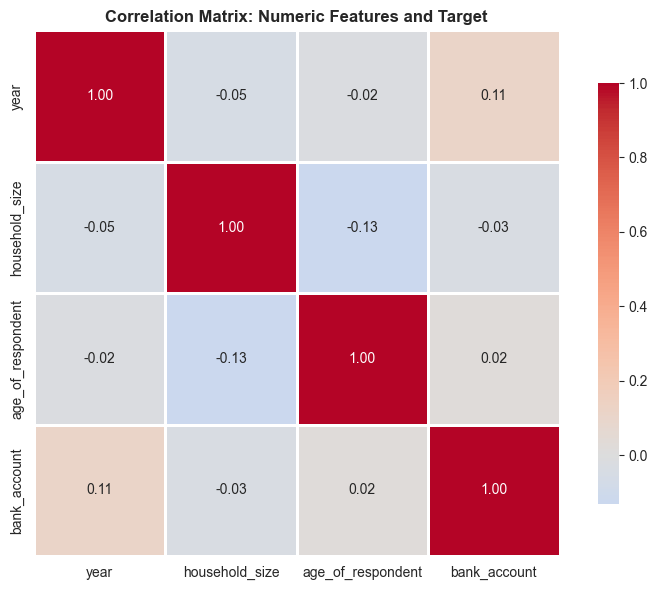

In [23]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(8, 6))
correlation_matrix = train_encoded[numeric_cols + ['bank_account']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Numeric Features and Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## What Correlation Means

### Correlation Values Explained:
- **1.0** = Perfect positive correlation (as one increases, other increases)
- **0.5** = Strong positive correlation
- **0.0** = No correlation (not related)
- **-0.5** = Strong negative correlation (as one increases, other decreases)
- **-1.0** = Perfect negative correlation

### For Your Data:
- **Year (0.11)**: Slightly related — people surveyed in 2018 are more likely to have bank accounts
- **Age (0.02)**: Almost no relationship with bank account ownership
- **Household size (-0.03)**: Almost no relationship (maybe slightly fewer people in smaller households have accounts)

### Visualization:
The **heatmap** shows these correlations visually with colors:
- 🔴 **Red** = Positive correlation
- 🔵 **Blue** = Negative correlation

### 9. Multi-dimensional Analysis

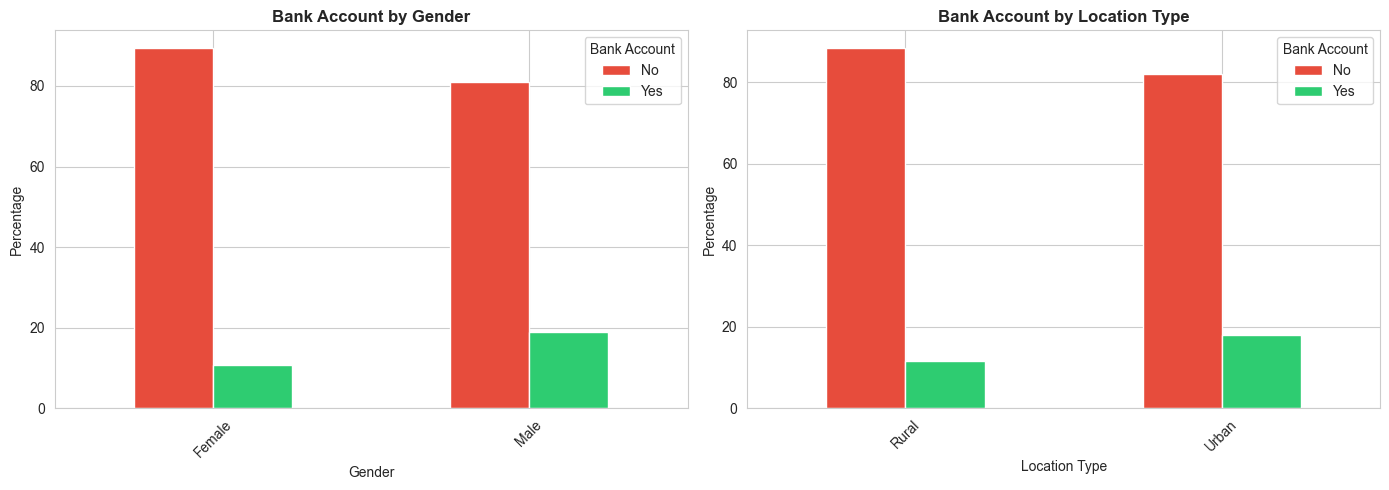

In [24]:
# Gender vs Location vs Bank Account
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Gender
gender_ba = pd.crosstab(train['gender_of_respondent'], train['bank_account'], normalize='index') * 100
gender_ba.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Bank Account by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Bank Account', labels=['No', 'Yes'])

# By Location Type
location_ba = pd.crosstab(train['location_type'], train['bank_account'], normalize='index') * 100
location_ba.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Bank Account by Location Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Location Type')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Bank Account', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

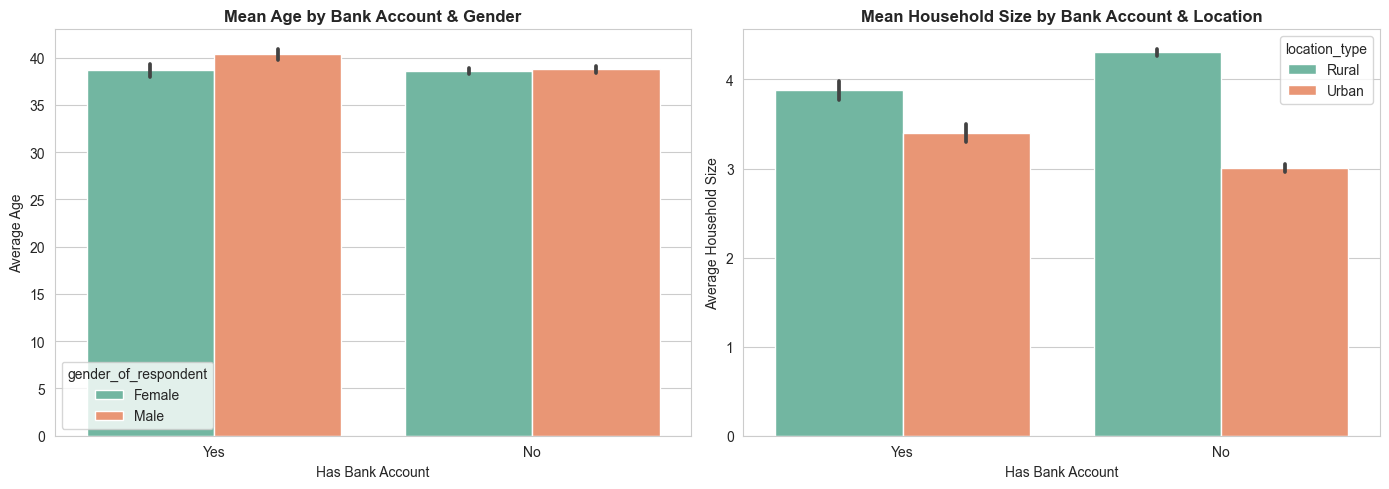

In [25]:
# Age and Household Size by Bank Account with Group Breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean age by Bank Account and Gender
sns.barplot(data=train, x='bank_account', y='age_of_respondent', hue='gender_of_respondent', 
            ax=axes[0], palette='Set2')
axes[0].set_title('Mean Age by Bank Account & Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Has Bank Account')
axes[0].set_ylabel('Average Age')

# Mean household size by Bank Account and Location
sns.barplot(data=train, x='bank_account', y='household_size', hue='location_type', 
            ax=axes[1], palette='Set2')
axes[1].set_title('Mean Household Size by Bank Account & Location', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Has Bank Account')
axes[1].set_ylabel('Average Household Size')

plt.tight_layout()
plt.show()

### 10. Summary & Key Insights

In [26]:
print("="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

print(f"\n1. DATASET SIZE & COMPOSITION:")
print(f"   - Training set: {train.shape[0]} records, {train.shape[1]} features")
print(f"   - Test set: {test.shape[0]} records")
print(f"   - No missing values in training data")

yes_pct = (train['bank_account'] == 'Yes').sum() / len(train) * 100
print(f"\n2. TARGET VARIABLE (Bank Account):")
print(f"   - Class distribution: {yes_pct:.1f}% Yes, {100-yes_pct:.1f}% No")
print(f"   - Imbalance ratio: {(train['bank_account']=='No').sum() / (train['bank_account']=='Yes').sum():.2f}:1")

print(f"\n3. NUMERIC FEATURES:")
print(f"   - year: {train['year'].min()}-{train['year'].max()}")
print(f"   - age_of_respondent: {train['age_of_respondent'].min()}-{train['age_of_respondent'].max()} years (mean: {train['age_of_respondent'].mean():.1f})")
print(f"   - household_size: {train['household_size'].min()}-{train['household_size'].max()} people (mean: {train['household_size'].mean():.1f})")

print(f"\n4. CATEGORICAL FEATURES:")
print(f"   - country: {train['country'].nunique()} unique country")
print(f"   - location_type: {train['location_type'].unique().tolist()}")
print(f"   - gender_of_respondent: {train['gender_of_respondent'].unique().tolist()}")
print(f"   - Most common job type: {train['job_type'].value_counts().index[0]}")
print(f"   - Most common education level: {train['education_level'].value_counts().index[0]}")

print(f"\n5. STRONGEST PREDICTORS (Univariate Analysis):")
print(f"   - Numeric: age_of_respondent, household_size, year")
print(f"   - Categorical: job_type, education_level, cellphone_access")

print(f"\n6. DATA QUALITY:")
print(f"   - No missing values detected")
print(f"   - No significant outliers in numeric features")
print(f"   - All features are complete and usable")

print("\n" + "="*60)

KEY INSIGHTS FROM EDA

1. DATASET SIZE & COMPOSITION:
   - Training set: 23524 records, 13 features
   - Test set: 10086 records
   - No missing values in training data

2. TARGET VARIABLE (Bank Account):
   - Class distribution: 14.1% Yes, 85.9% No
   - Imbalance ratio: 6.10:1

3. NUMERIC FEATURES:
   - year: 2016-2018
   - age_of_respondent: 16-100 years (mean: 38.8)
   - household_size: 1-21 people (mean: 3.8)

4. CATEGORICAL FEATURES:
   - country: 4 unique country
   - location_type: ['Rural', 'Urban']
   - gender_of_respondent: ['Female', 'Male']
   - Most common job type: Self employed
   - Most common education level: Primary education

5. STRONGEST PREDICTORS (Univariate Analysis):
   - Numeric: age_of_respondent, household_size, year
   - Categorical: job_type, education_level, cellphone_access

6. DATA QUALITY:
   - No missing values detected
   - No significant outliers in numeric features
   - All features are complete and usable

